## Skeleton-Transformer v5 — Training Fix on Best Data

Uses existing `../M4B_skeleton_clips_v2` data (the best performing data).

**The key insight from all experiments:**
Every single training run peaked at epoch 1-5 during the HEAD-only phase, then declined after unfreezing the Transformer body. The unfreezing step consistently destroyed the good initial features.

**What v5 tests (5 configurations):**

- A: Head-only (NEVER unfreeze) — train just the classifier for 80 epochs on frozen Transformer features
- B: Head-only + OneCycleLR — start low, peak at epoch 5, decay to near-zero (locks in early features)
- C: Head-only + smaller head — Linear(128→3) direct (less capacity to overfit)
- D: Head-only + 2-layer head + dropout=0.5 — more regularization
- E: Very late unfreeze — head for 40 epochs, then unfreeze with lr=1e-5 (10x lower than before)

All use Config B architecture (d=128, 4 layers), v2 data, original v3 features (with inter-person).

In [1]:
import os, cv2, gc, random, time, sys, math, copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts, OneCycleLR
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import recall_score, precision_score
from pathlib import Path
import matplotlib.pyplot as plt

SKEL_ROOT        = r'../M4B_skeleton_clips_v2'
TARGET_CLASSES   = ['Violence', 'Threat', 'Normal']
SKEL_CLIP_FRAMES = 16
MAX_PERSONS      = 2
N_KEYPOINTS      = 17

EPOCHS    = 80
BATCH     = 32
PATIENCE  = 30
EMA_DECAY = 0.998
SAVE_DIR  = r'runs/M4B_classifier/TransformerV5'

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

for split in ['train', 'val']:
    total = sum(len(list((Path(SKEL_ROOT)/split/c).glob('*.npy')))
                for c in TARGET_CLASSES if (Path(SKEL_ROOT)/split/c).exists())
    print(f'  {split}: {total:,} clips')


Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
  train: 11,200 clips
  val: 2,800 clips


In [2]:
BONES = [(5,7),(7,9),(6,8),(8,10),(5,6),(11,13),(13,15),(12,14),(14,16),(11,12),(5,11),(6,12),(0,5),(0,6),(0,1),(0,2)]
ANGLE_TRIPLETS = [(5,7,9),(6,8,10),(11,13,15),(12,14,16),(5,0,6)]

def compute_bones(kps):
    out = []
    for j1, j2 in BONES:
        dx, dy = kps[j1,0]-kps[j2,0], kps[j1,1]-kps[j2,1]
        out.append(math.sqrt(dx*dx + dy*dy + 1e-8))
    return np.array(out, dtype=np.float32)

def compute_angles(kps):
    out = []
    for a, v, b in ANGLE_TRIPLETS:
        va, vb = kps[a]-kps[v], kps[b]-kps[v]
        c = np.dot(va, vb) / (np.linalg.norm(va)*np.linalg.norm(vb) + 1e-8)
        out.append(math.acos(np.clip(c, -1, 1)) / math.pi)
    return np.array(out, dtype=np.float32)

def compute_inter(k1, k2):
    c1, c2 = k1[:,:2].mean(0), k2[:,:2].mean(0)
    cd = np.linalg.norm(c1-c2)
    md = np.linalg.norm(k1[:,:2][:,None]-k2[:,:2][None,:], axis=2).min()
    hh = min(np.linalg.norm(k1[9,:2]-k2[0,:2]), np.linalg.norm(k1[10,:2]-k2[0,:2]),
             np.linalg.norm(k2[9,:2]-k1[0,:2]), np.linalg.norm(k2[10,:2]-k1[0,:2]))
    return np.array([cd, md, hh], dtype=np.float32)

class V5Dataset(Dataset):
    def __init__(self, root, split, classes, augment=False, feat_mean=None, feat_std=None):
        self.samples, self.augment = [], augment
        self.feat_mean, self.feat_std = feat_mean, feat_std
        base = Path(root) / split
        for ci, cls in enumerate(classes):
            d = base / cls
            if d.exists():
                for p in d.glob('*.npy'):
                    self.samples.append((p, ci))
        random.shuffle(self.samples)

    def __len__(self): return len(self.samples)

    def _mask(self, clip):
        for p in range(MAX_PERSONS):
            valid = clip[:, p, :, 2] > 0.3
            for j in range(N_KEYPOINTS):
                if valid[:, j].sum() > 0:
                    mp = clip[valid[:, j], p, j, :2].mean(0)
                else:
                    mp = np.array([0.5, 0.5])
                for t in range(clip.shape[0]):
                    if not valid[t, j]:
                        clip[t, p, j, :2] = mp; clip[t, p, j, 2] = 0.0
        return clip

    def _build(self, clip):
        T = clip.shape[0]
        clip = self._mask(clip)
        rows = []
        for t in range(T):
            f = []
            for p in range(MAX_PERSONS):
                k = clip[t, p]
                f.extend([k[:,:2].flatten(), k[:,2], compute_bones(k), compute_angles(k)])
            f.append(compute_inter(clip[t,0], clip[t,1]))
            rows.append(np.concatenate(f))
        feat = np.stack(rows)
        psize = 34+17+16+5
        for p in range(MAX_PERSONS):
            s = p * psize
            pos = feat[:, s:s+34]
            vel = np.zeros_like(pos); vel[1:] = pos[1:]-pos[:-1]
            acc = np.zeros_like(vel); acc[2:] = vel[2:]-vel[1:-1]
            feat = np.concatenate([feat, vel, acc], axis=1)
        return feat

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        clip = np.load(str(path)).copy()
        if self.augment:
            if random.random() > 0.5:
                clip[:,:,:,0] = 1.0 - clip[:,:,:,0]
                for l, r in [(1,2),(3,4),(5,6),(7,8),(9,10),(11,12),(13,14),(15,16)]:
                    clip[:,:,[l,r]] = clip[:,:,[r,l]]
            dx, dy = random.uniform(-0.05,0.05), random.uniform(-0.05,0.05)
            clip[:,:,:,0] = np.clip(clip[:,:,:,0]+dx, 0, 1)
            clip[:,:,:,1] = np.clip(clip[:,:,:,1]+dy, 0, 1)
            s = random.uniform(0.85, 1.15)
            for p in range(MAX_PERSONS):
                cx, cy = clip[:,p,:,0].mean(), clip[:,p,:,1].mean()
                clip[:,p,:,0] = np.clip((clip[:,p,:,0]-cx)*s+cx, 0, 1)
                clip[:,p,:,1] = np.clip((clip[:,p,:,1]-cy)*s+cy, 0, 1)
        feat = self._build(clip)
        if self.feat_mean is not None:
            feat = (feat - self.feat_mean) / (self.feat_std + 1e-8)
        return torch.tensor(feat, dtype=torch.float32), label

print('Computing standardization stats...')
tmp = V5Dataset(SKEL_ROOT, 'train', TARGET_CLASSES)
samps = [tmp[i][0].numpy() for i in range(min(2000, len(tmp)))]
af = np.concatenate(samps, axis=0)
FEAT_MEAN = af.mean(axis=0)
FEAT_STD = af.std(axis=0)
FEAT_DIM = FEAT_MEAN.shape[0]
del tmp, samps, af
print(f'Feature dim: {FEAT_DIM} ✅')


Computing standardization stats...
Feature dim: 283 ✅


In [3]:
class SkeletonTransformer(nn.Module):
    def __init__(self, input_dim, num_classes=3, d_model=128,
                 nhead=4, num_layers=4, dim_ff=256, dropout=0.3,
                 head_type='standard'):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, d_model), nn.LayerNorm(d_model),
            nn.Dropout(dropout * 0.3))
        self.pos_embed = nn.Parameter(torch.randn(1, SKEL_CLIP_FRAMES, d_model) * 0.02)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)
        enc = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, activation='gelu', norm_first=True)
        self.transformer = nn.TransformerEncoder(enc, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)

        if head_type == 'minimal':
            self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(d_model, num_classes))
        elif head_type == 'regularized':
            self.head = nn.Sequential(
                nn.Dropout(0.5), nn.Linear(d_model, 32),
                nn.GELU(), nn.Dropout(0.3), nn.Linear(32, num_classes))
        else:  # standard
            self.head = nn.Sequential(
                nn.Dropout(dropout), nn.Linear(d_model, d_model//2),
                nn.GELU(), nn.Dropout(dropout*0.5), nn.Linear(d_model//2, num_classes))

    def forward(self, x):
        B = x.shape[0]
        x = self.input_proj(x)
        x = torch.cat([self.cls_token.expand(B,-1,-1), x], dim=1)
        pos = torch.cat([torch.zeros(1,1,x.shape[2],device=x.device), self.pos_embed], dim=1)
        x = self.transformer(x + pos)
        return self.head(self.norm(x[:, 0]))

class EMA:
    def __init__(self, model, decay=0.998):
        self.decay = decay
        self.shadow = {n: p.data.clone() for n, p in model.named_parameters() if p.requires_grad}
    def update(self, model):
        for n, p in model.named_parameters():
            if p.requires_grad and n in self.shadow:
                self.shadow[n] = self.decay*self.shadow[n] + (1-self.decay)*p.data
    def apply(self, model):
        bk = {}
        for n, p in model.named_parameters():
            if n in self.shadow: bk[n] = p.data.clone(); p.data = self.shadow[n].clone()
        return bk
    def restore(self, model, bk):
        for n, p in model.named_parameters():
            if n in bk: p.data = bk[n]

def get_m(yt, yp, cls, metric='recall'):
    ci = TARGET_CLASSES.index(cls)
    fn = recall_score if metric == 'recall' else precision_score
    r = fn(yt, yp, labels=[ci], average=None, zero_division=0)
    return float(r[0]) if len(r) > 0 else 0.0

print('Model variants:')
for ht in ['standard', 'minimal', 'regularized']:
    m = SkeletonTransformer(FEAT_DIM, head_type=ht)
    p = sum(pp.numel() for pp in m.parameters())
    print(f'  head={ht:<14} {p:,} params')
    del m


Model variants:
  head=standard       577,411 params
  head=minimal        569,347 params
  head=regularized    573,187 params


C:\Users\jingy\AppData\Local\Temp\ipykernel_29588\1028104165.py:14: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(enc, num_layers=num_layers)


### Run 5 head-only training configurations

The Transformer body stays FROZEN for all configs. Only the classifier head trains. This is the key change — previous experiments always unfroze and always declined after unfreezing.

In [4]:
def run_head_only(name, head_type='standard', lr=1e-3, use_onecycle=False,
                  unfreeze_epoch=None, unfreeze_lr=1e-5):
    save_path = str(Path(SAVE_DIR) / f'{name}.pt')
    Path(SAVE_DIR).mkdir(parents=True, exist_ok=True)

    train_ds = V5Dataset(SKEL_ROOT, 'train', TARGET_CLASSES,
                          augment=True, feat_mean=FEAT_MEAN, feat_std=FEAT_STD)
    val_ds   = V5Dataset(SKEL_ROOT, 'val', TARGET_CLASSES,
                          augment=False, feat_mean=FEAT_MEAN, feat_std=FEAT_STD)
    train_ld = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=0, pin_memory=True)
    val_ld   = DataLoader(val_ds, batch_size=BATCH, shuffle=False, num_workers=0, pin_memory=True)

    counts = [len(list((Path(SKEL_ROOT)/'train'/c).glob('*.npy'))) for c in TARGET_CLASSES]
    total = sum(counts)
    wts = torch.tensor([total/(3*c) for c in counts], dtype=torch.float).to(DEVICE)

    model = SkeletonTransformer(FEAT_DIM, head_type=head_type).to(DEVICE)
    ema = EMA(model, EMA_DECAY)
    criterion = nn.CrossEntropyLoss(weight=wts)

    # Freeze body
    head_params = list(model.head.parameters()) + list(model.norm.parameters())
    body_params = [p for n,p in model.named_parameters() if not any(x in n for x in ['head','norm'])]
    for p in body_params: p.requires_grad = False

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    optimizer = optim.AdamW(head_params, lr=lr, weight_decay=1e-2)

    if use_onecycle:
        scheduler = OneCycleLR(optimizer, max_lr=lr, epochs=EPOCHS,
                               steps_per_epoch=len(train_ld), pct_start=0.1,
                               anneal_strategy='cos', final_div_factor=100)
        sched_type = 'OneCycleLR'
    else:
        scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=20, T_mult=2, eta_min=1e-6)
        sched_type = 'CosineWarmRestart'

    unfreeze_tag = f', unfreeze@{unfreeze_epoch} lr={unfreeze_lr}' if unfreeze_epoch else ', NEVER unfreeze'
    print(f'\n{"="*70}')
    print(f'  {name}')
    print(f'  head={head_type}, lr={lr}, sched={sched_type}{unfreeze_tag}')
    print(f'  Trainable: {trainable:,} / {sum(p.numel() for p in model.parameters()):,}')
    print(f'{"="*70}')
    sys.stdout.flush()

    best_f1, best_ema_f1, pat = 0.0, 0.0, 0
    history = {'loss': [], 'f1': [], 'f1_ema': []}
    best_yt, best_yp = [], []
    unfrozen = False
    t0 = time.time()

    for epoch in range(1, EPOCHS+1):
        # Late unfreeze
        if unfreeze_epoch and epoch == unfreeze_epoch and not unfrozen:
            print(f'  >>> UNFREEZING (lr={unfreeze_lr}) <<<')
            unfrozen = True
            for p in body_params: p.requires_grad = True
            ema = EMA(model, EMA_DECAY)
            optimizer = optim.AdamW(model.parameters(), lr=unfreeze_lr, weight_decay=1e-2)
            if use_onecycle:
                remaining = EPOCHS - epoch + 1
                scheduler = OneCycleLR(optimizer, max_lr=unfreeze_lr, epochs=remaining,
                                       steps_per_epoch=len(train_ld), pct_start=0.05,
                                       final_div_factor=100)
            else:
                scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=15, T_mult=2, eta_min=1e-7)

        model.train()
        tloss = 0.0
        for clips, labels in train_ld:
            clips, labels = clips.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(clips), labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            if use_onecycle:
                scheduler.step()
            ema.update(model)
            tloss += loss.item()
        tloss /= len(train_ld)
        if not use_onecycle:
            scheduler.step()

        model.eval()
        yt, yp = [], []
        with torch.no_grad():
            for c, l in val_ld:
                yp.extend(model(c.to(DEVICE)).argmax(1).cpu().numpy())
                yt.extend(l.numpy())
        vf1 = f1_score(yt, yp, average='weighted', zero_division=0)

        bk = ema.apply(model)
        yte, ype = [], []
        with torch.no_grad():
            for c, l in val_ld:
                ype.extend(model(c.to(DEVICE)).argmax(1).cpu().numpy())
                yte.extend(l.numpy())
        vfe = f1_score(yte, ype, average='weighted', zero_division=0)
        ema.restore(model, bk)

        history['loss'].append(tloss); history['f1'].append(vf1); history['f1_ema'].append(vfe)

        imp = ''
        if vf1 > best_f1:
            best_f1, pat = vf1, 0; imp = ' ✅'
            if vf1 >= best_ema_f1: best_yt, best_yp = yt, yp
            torch.save(model.state_dict(), save_path)
        else: pat += 1
        if vfe > best_ema_f1:
            best_ema_f1 = vfe; imp += ' ✅(ema)'
            if vfe > best_f1: best_yt, best_yp = yte, ype
            bk2 = ema.apply(model)
            torch.save(model.state_dict(), save_path.replace('.pt','_ema.pt'))
            ema.restore(model, bk2)

        stage = 'HEAD' if not unfrozen else 'FULL'
        if epoch<=5 or epoch%10==0 or imp or pat>=PATIENCE-3 or (unfreeze_epoch and epoch==unfreeze_epoch):
            m, s = divmod(int(time.time()-t0), 60)
            print(f'  ep {epoch:>3} [{stage}] loss={tloss:.4f} f1={vf1:.4f} ema={vfe:.4f} {m}m{s:02d}s{imp}')
            sys.stdout.flush()
        if pat >= PATIENCE:
            print(f'  Early stop at epoch {epoch}'); break

    best_overall = max(best_f1, best_ema_f1)
    m, s = divmod(int(time.time()-t0), 60)
    print(f'  Done {m}m{s:02d}s — Best: {best_overall:.4f}')

    del model; gc.collect()
    if DEVICE == 'cuda': torch.cuda.empty_cache()

    return {'name': name, 'best_f1': best_overall, 'reg_f1': best_f1, 'ema_f1': best_ema_f1,
            'history': history, 'y_true': best_yt, 'y_pred': best_yp}


# ── Run all 5 ─────────────────────────────────────────────────────────────────
results = []

results.append(run_head_only('A_HeadOnly_Cosine',
    head_type='standard', lr=1e-3, use_onecycle=False))

results.append(run_head_only('B_HeadOnly_OneCycle',
    head_type='standard', lr=1e-3, use_onecycle=True))

results.append(run_head_only('C_MinimalHead',
    head_type='minimal', lr=5e-4, use_onecycle=True))

results.append(run_head_only('D_RegHead',
    head_type='regularized', lr=1e-3, use_onecycle=True))

results.append(run_head_only('E_LateUnfreeze',
    head_type='standard', lr=1e-3, use_onecycle=True,
    unfreeze_epoch=40, unfreeze_lr=1e-5))

print('\nAll done ✅')


C:\Users\jingy\AppData\Local\Temp\ipykernel_29588\1028104165.py:14: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(enc, num_layers=num_layers)



  A_HeadOnly_Cosine
  head=standard, lr=0.001, sched=CosineWarmRestart, NEVER unfreeze
  Trainable: 10,755 / 577,411
  ep   1 [HEAD] loss=0.8767 f1=0.5173 ema=0.4977 3m39s ✅ ✅(ema)
  ep   2 [HEAD] loss=0.8109 f1=0.4891 ema=0.5210 5m45s ✅(ema)
  ep   3 [HEAD] loss=0.7861 f1=0.5349 ema=0.5212 7m49s ✅ ✅(ema)
  ep   4 [HEAD] loss=0.7747 f1=0.4958 ema=0.5018 10m01s
  ep   5 [HEAD] loss=0.7575 f1=0.4967 ema=0.4946 12m12s
  ep  10 [HEAD] loss=0.7335 f1=0.4747 ema=0.4712 22m52s
  ep  20 [HEAD] loss=0.7122 f1=0.4628 ema=0.4648 44m14s
  ep  30 [HEAD] loss=0.7013 f1=0.4640 ema=0.4600 64m56s
  ep  31 [HEAD] loss=0.6992 f1=0.4472 ema=0.4605 67m11s
  ep  32 [HEAD] loss=0.7013 f1=0.4519 ema=0.4620 69m15s
  ep  33 [HEAD] loss=0.6910 f1=0.4559 ema=0.4622 71m29s
  Early stop at epoch 33
  Done 71m29s — Best: 0.5349

  B_HeadOnly_OneCycle
  head=standard, lr=0.001, sched=OneCycleLR, NEVER unfreeze
  Trainable: 10,755 / 577,411


C:\Users\jingy\AppData\Local\Temp\ipykernel_29588\1028104165.py:14: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(enc, num_layers=num_layers)


  ep   1 [HEAD] loss=1.0559 f1=0.4282 ema=0.2951 2m14s ✅ ✅(ema)
  ep   2 [HEAD] loss=0.9530 f1=0.5470 ema=0.4513 4m23s ✅ ✅(ema)
  ep   3 [HEAD] loss=0.8700 f1=0.5490 ema=0.5443 6m36s ✅ ✅(ema)
  ep   4 [HEAD] loss=0.8397 f1=0.5522 ema=0.5454 8m48s ✅ ✅(ema)
  ep   5 [HEAD] loss=0.8153 f1=0.5394 ema=0.5488 11m00s ✅(ema)
  ep  10 [HEAD] loss=0.7537 f1=0.4552 ema=0.4845 21m18s
  ep  20 [HEAD] loss=0.7112 f1=0.4642 ema=0.4568 40m50s
  ep  30 [HEAD] loss=0.6902 f1=0.4940 ema=0.4513 60m26s
  ep  31 [HEAD] loss=0.6857 f1=0.4473 ema=0.4514 62m23s
  ep  32 [HEAD] loss=0.6792 f1=0.4510 ema=0.4519 64m20s
  ep  33 [HEAD] loss=0.6868 f1=0.4510 ema=0.4526 66m17s
  ep  34 [HEAD] loss=0.6834 f1=0.4506 ema=0.4539 68m14s
  Early stop at epoch 34
  Done 68m14s — Best: 0.5522

  C_MinimalHead
  head=minimal, lr=0.0005, sched=OneCycleLR, NEVER unfreeze
  Trainable: 2,691 / 569,347


C:\Users\jingy\AppData\Local\Temp\ipykernel_29588\1028104165.py:14: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(enc, num_layers=num_layers)


  ep   1 [HEAD] loss=1.2039 f1=0.3716 ema=0.3314 1m57s ✅ ✅(ema)
  ep   2 [HEAD] loss=1.1072 f1=0.4866 ema=0.3754 3m54s ✅ ✅(ema)
  ep   3 [HEAD] loss=1.0177 f1=0.5281 ema=0.4810 5m51s ✅ ✅(ema)
  ep   4 [HEAD] loss=0.9655 f1=0.5294 ema=0.5209 7m48s ✅ ✅(ema)
  ep   5 [HEAD] loss=0.9280 f1=0.5547 ema=0.5383 9m46s ✅ ✅(ema)
  ep   6 [HEAD] loss=0.9116 f1=0.5564 ema=0.5498 11m42s ✅ ✅(ema)
  ep   7 [HEAD] loss=0.8999 f1=0.5525 ema=0.5509 13m39s ✅(ema)
  ep   8 [HEAD] loss=0.8922 f1=0.5768 ema=0.5527 15m36s ✅ ✅(ema)
  ep   9 [HEAD] loss=0.8913 f1=0.5522 ema=0.5570 17m33s ✅(ema)
  ep  10 [HEAD] loss=0.8889 f1=0.5495 ema=0.5600 19m30s ✅(ema)
  ep  20 [HEAD] loss=0.8825 f1=0.5629 ema=0.5608 39m02s ✅(ema)
  ep  23 [HEAD] loss=0.8866 f1=0.5681 ema=0.5612 44m54s ✅(ema)
  ep  24 [HEAD] loss=0.8876 f1=0.5624 ema=0.5618 46m51s ✅(ema)
  ep  25 [HEAD] loss=0.8844 f1=0.5589 ema=0.5629 48m49s ✅(ema)
  ep  30 [HEAD] loss=0.8826 f1=0.5533 ema=0.5616 58m36s
  ep  35 [HEAD] loss=0.8838 f1=0.5571 ema=0.5621 68m2

C:\Users\jingy\AppData\Local\Temp\ipykernel_29588\1028104165.py:14: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(enc, num_layers=num_layers)


  ep   1 [HEAD] loss=1.0852 f1=0.3596 ema=0.2419 1m57s ✅ ✅(ema)
  ep   2 [HEAD] loss=1.0132 f1=0.4392 ema=0.3704 3m54s ✅ ✅(ema)
  ep   3 [HEAD] loss=0.9517 f1=0.4567 ema=0.4292 5m52s ✅ ✅(ema)
  ep   4 [HEAD] loss=0.9149 f1=0.5195 ema=0.4515 7m50s ✅ ✅(ema)
  ep   5 [HEAD] loss=0.8909 f1=0.4836 ema=0.4677 9m47s ✅(ema)
  ep   6 [HEAD] loss=0.8721 f1=0.4924 ema=0.4744 11m45s ✅(ema)
  ep   7 [HEAD] loss=0.8686 f1=0.4829 ema=0.4789 13m42s ✅(ema)
  ep   8 [HEAD] loss=0.8591 f1=0.4763 ema=0.4799 15m39s ✅(ema)
  ep   9 [HEAD] loss=0.8556 f1=0.4762 ema=0.4818 17m37s ✅(ema)
  ep  10 [HEAD] loss=0.8455 f1=0.4809 ema=0.4857 19m41s ✅(ema)
  ep  20 [HEAD] loss=0.8228 f1=0.4629 ema=0.4644 39m50s
  ep  30 [HEAD] loss=0.8095 f1=0.4620 ema=0.4590 60m02s
  ep  31 [HEAD] loss=0.8139 f1=0.4542 ema=0.4635 62m06s
  ep  32 [HEAD] loss=0.8235 f1=0.4668 ema=0.4545 64m11s
  ep  33 [HEAD] loss=0.8166 f1=0.4506 ema=0.4535 66m16s
  ep  34 [HEAD] loss=0.8130 f1=0.4463 ema=0.4584 68m21s
  Early stop at epoch 34
  Done

C:\Users\jingy\AppData\Local\Temp\ipykernel_29588\1028104165.py:14: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(enc, num_layers=num_layers)


  ep   1 [HEAD] loss=1.0463 f1=0.4790 ema=0.4869 2m02s ✅ ✅(ema)
  ep   2 [HEAD] loss=0.9427 f1=0.5071 ema=0.5041 3m59s ✅ ✅(ema)
  ep   3 [HEAD] loss=0.8718 f1=0.5000 ema=0.5060 5m56s ✅(ema)
  ep   4 [HEAD] loss=0.8365 f1=0.5264 ema=0.5140 7m53s ✅ ✅(ema)
  ep   5 [HEAD] loss=0.8107 f1=0.4788 ema=0.5045 9m50s
  ep  10 [HEAD] loss=0.7438 f1=0.4580 ema=0.4672 19m37s
  ep  20 [HEAD] loss=0.6915 f1=0.4467 ema=0.4398 39m20s
  ep  30 [HEAD] loss=0.6729 f1=0.4251 ema=0.4215 59m08s
  ep  31 [HEAD] loss=0.6742 f1=0.4559 ema=0.4253 61m07s
  ep  32 [HEAD] loss=0.6709 f1=0.4315 ema=0.4386 63m06s
  ep  33 [HEAD] loss=0.6695 f1=0.4364 ema=0.4396 65m04s
  ep  34 [HEAD] loss=0.6746 f1=0.4312 ema=0.4413 67m03s
  Early stop at epoch 34
  Done 67m03s — Best: 0.5264

All done ✅


  V5 HEAD-ONLY TRAINING RESULTS
  Config                          Best F1     Reg     EMA   VioR   ThrR   NorR
  --------------------------------------------------------------------------------
  CNN+LSTM v3 (ref)                 0.638                   0.57   0.26   0.92
  Skel-Trans B v1 (prev best)       0.579                   0.73   0.55   0.48
  --------------------------------------------------------------------------------
  A_HeadOnly_Cosine                0.5349  0.5349  0.5212   0.69   0.66   0.37
  B_HeadOnly_OneCycle              0.5522  0.5522  0.5488   0.72   0.56   0.43
  C_MinimalHead                    0.5768  0.5768  0.5629   0.65   0.66   0.46
  D_RegHead                        0.5195  0.5195  0.4857   0.56   0.67   0.39
  E_LateUnfreeze                   0.5264  0.5264  0.5140   0.73   0.60   0.35
  --------------------------------------------------------------------------------
  Winner: C_MinimalHead (F1=0.5768)

Per-class — C_MinimalHead:
              precision

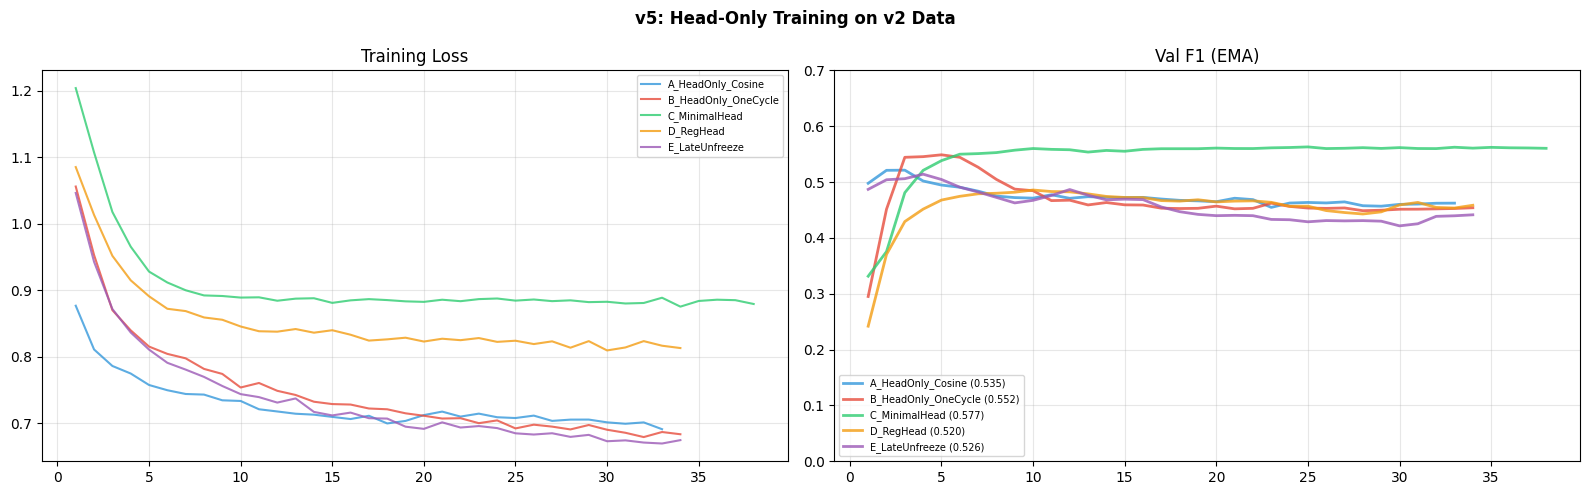

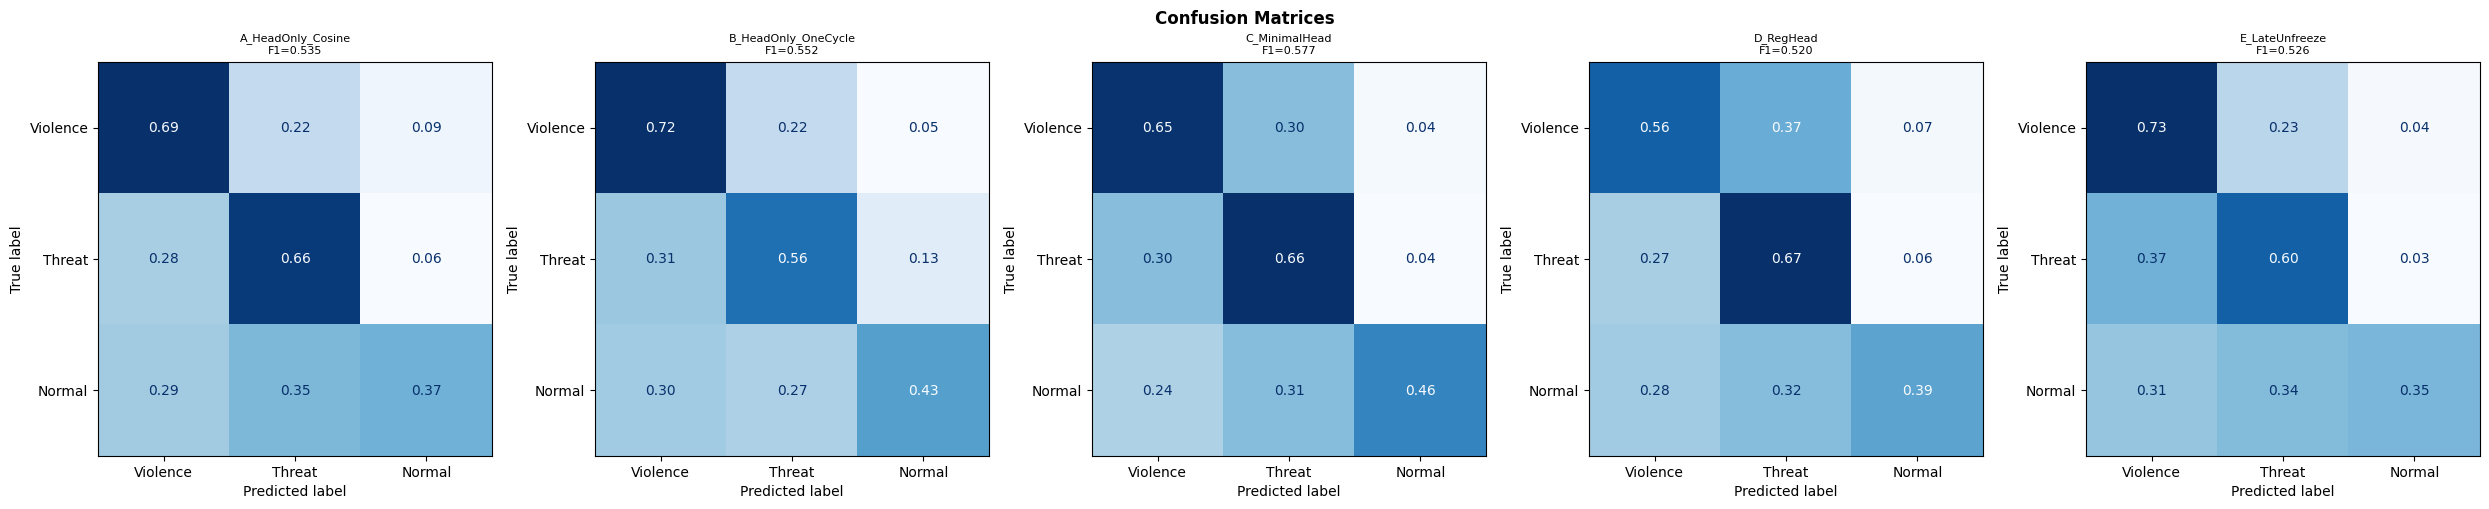


📈 Improved: 0.577 (prev best 0.579 with unfreeze)

Weights: runs/M4B_classifier/TransformerV5/


In [5]:
print('='*95)
print('  V5 HEAD-ONLY TRAINING RESULTS')
print('='*95)
print(f'  {"Config":<30} {"Best F1":>8} {"Reg":>7} {"EMA":>7} {"VioR":>6} {"ThrR":>6} {"NorR":>6}')
print('  ' + '-'*80)

# References
print(f'  {"CNN+LSTM v3 (ref)":<30} {"0.638":>8} {"":>7} {"":>7} {"0.57":>6} {"0.26":>6} {"0.92":>6}')
print(f'  {"Skel-Trans B v1 (prev best)":<30} {"0.579":>8} {"":>7} {"":>7} {"0.73":>6} {"0.55":>6} {"0.48":>6}')
print('  ' + '-'*80)

best_r = None
for r in results:
    yt, yp = np.array(r['y_true']), np.array(r['y_pred'])
    vr = get_m(yt, yp, 'Violence')
    tr = get_m(yt, yp, 'Threat')
    nr = get_m(yt, yp, 'Normal')
    if best_r is None or r['best_f1'] > best_r['best_f1']:
        best_r = r
    print(f'  {r["name"]:<30} {r["best_f1"]:>8.4f} {r["reg_f1"]:>7.4f} {r["ema_f1"]:>7.4f} {vr:>6.2f} {tr:>6.2f} {nr:>6.2f}')

print('  ' + '-'*80)
print(f'  Winner: {best_r["name"]} (F1={best_r["best_f1"]:.4f})')
print('='*95)

# Per-class for winner
print(f'\nPer-class — {best_r["name"]}:')
print(classification_report(np.array(best_r['y_true']), np.array(best_r['y_pred']),
      target_names=TARGET_CLASSES, zero_division=0))

# Training curves
colors = ['#3498DB', '#E74C3C', '#2ECC71', '#F39C12', '#9B59B6']
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for r, c in zip(results, colors):
    ex = range(1, len(r['history']['f1'])+1)
    axes[0].plot(ex, r['history']['loss'], '-', color=c, linewidth=1.5, label=r['name'], alpha=0.8)
    axes[1].plot(ex, r['history']['f1_ema'], '-', color=c, linewidth=2,
                 label=f'{r["name"]} ({r["best_f1"]:.3f})', alpha=0.8)
axes[0].set_title('Training Loss'); axes[0].grid(alpha=0.3); axes[0].legend(fontsize=7)
axes[1].set_title('Val F1 (EMA)'); axes[1].set_ylim(0, 0.7); axes[1].grid(alpha=0.3); axes[1].legend(fontsize=7)
plt.suptitle('v5: Head-Only Training on v2 Data', fontweight='bold')
plt.tight_layout(); plt.show()

# Confusion matrices
fig, axes = plt.subplots(1, len(results), figsize=(5*len(results), 5))
if len(results) == 1: axes = [axes]
for ax, r in zip(axes, results):
    cm = confusion_matrix(r['y_true'], r['y_pred'])
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    ConfusionMatrixDisplay(cm_n, display_labels=TARGET_CLASSES).plot(
        ax=ax, colorbar=False, cmap='Blues', values_format='.2f')
    ax.set_title(f'{r["name"]}\nF1={r["best_f1"]:.3f}', fontsize=8)
plt.suptitle('Confusion Matrices', fontweight='bold')
plt.tight_layout(); plt.show()

# Verdict
w = best_r['best_f1']
print()
if w > 0.638:
    print(f'🏆 BEATS CNN+LSTM v3! ({w:.3f} vs 0.638)')
elif w > 0.579:
    print(f'🏆 New skeleton best! ({w:.3f} vs 0.579)')
elif w > 0.553:
    print(f'📈 Improved: {w:.3f} (prev best 0.579 with unfreeze)')
else:
    print(f'📊 Result: {w:.3f} (prev best: 0.579)')

print(f'\nWeights: {SAVE_DIR}/')
